Fine-tuned BERT

Setup and Installation:

In [1]:
!pip -q install -U transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.2 MB/s eta 0:00:00


In [2]:
import torch
import json
import random
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from wordcloud import WordCloud, STOPWORDS

Load Data:


In [4]:
print("Loading data...")

# Load training data (Mendeley)
with open('../mendeley_cleaned.json', 'r', encoding='utf-8') as f:
    train_data = json.load(f)

# Load test data (Kaggle)
with open('../kaggle_data.json', 'r', encoding='utf-8') as f:
    test_data = json.load(f)

print(f"Training samples (Mendeley): {len(train_data):,}")
print(f"Test samples (Kaggle): {len(test_data):,}")

Loading data...
Training samples (Mendeley): 53,920
Test samples (Kaggle): 117,458


In [5]:
# Prepare data
# Mendeley: 'review' + 'recommend'
X_all = [item["review"] for item in train_data]
y_all = [1 if item["recommend"] == "Recommended" else 0 for item in train_data]

# Kaggle: 'review_content' + 'is_positive'
X_test = [item["review_content"] for item in test_data]
y_test = [1 if item["is_positive"] else 0 for item in test_data]

print(f"Mendeley - Positive: {sum(y_all):,}, Negative: {len(y_all) - sum(y_all):,}")
print(f"Kaggle   - Positive: {sum(y_test):,}, Negative: {len(y_test) - sum(y_test):,}")

# Split Mendeley into train/val (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print(f"Mendeley split -> Train: {len(X_train):,}, Val: {len(X_val):,}")

Mendeley - Positive: 26,960, Negative: 26,960
Kaggle   - Positive: 55,789, Negative: 61,669
Mendeley split -> Train: 43,136, Val: 10,784


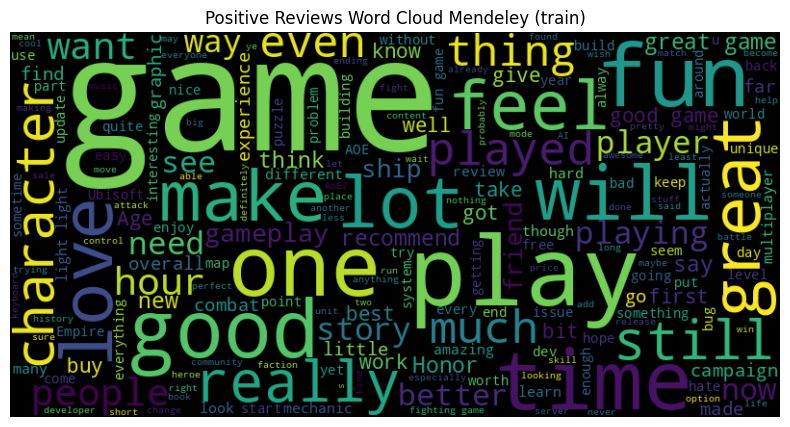

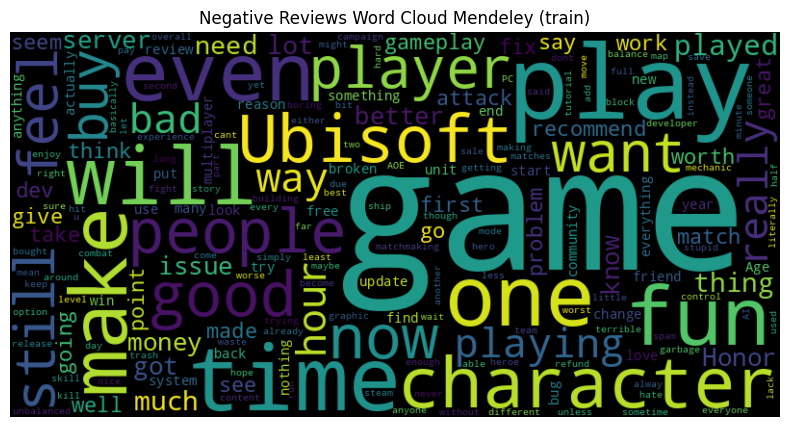

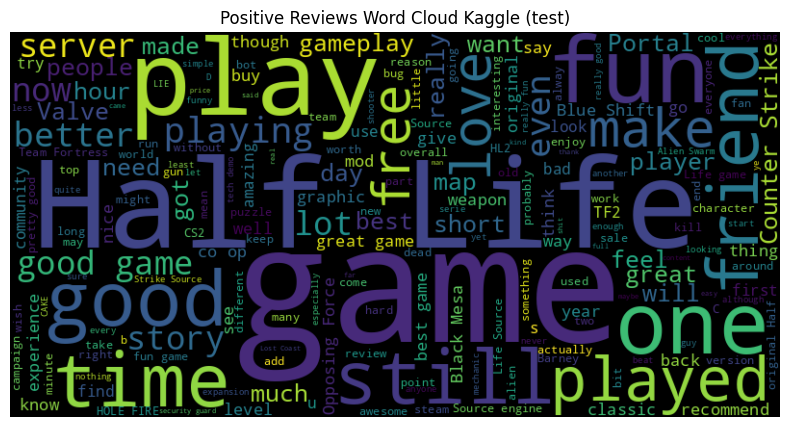

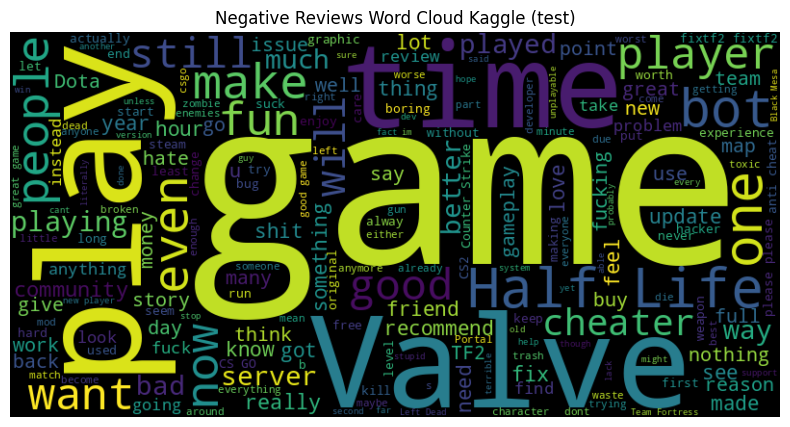

In [6]:
# Word cloud data analysis for Kaggle (test data)

positive_reviews_train = [text for text, label in zip(X_train, y_train) if label == 1]
negative_reviews_train = [text for text, label in zip(X_train, y_train) if label == 0]

positive_reviews_test = [text for text, label in zip(X_test, y_test) if label == 1]
negative_reviews_test = [text for text, label in zip(X_test, y_test) if label == 0]

def generate_wordcloud(text,Title):
    all_text = " ".join(text)
    wordcloud = WordCloud(width=800,
                          height=400,
                          stopwords=set(STOPWORDS),
                          background_color='black').generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(Title)
    plt.show()

generate_wordcloud(positive_reviews_train, "Positive Reviews Word Cloud Mendeley (train)")
generate_wordcloud(negative_reviews_train, "Negative Reviews Word Cloud Mendeley (train)")

generate_wordcloud(positive_reviews_test, "Positive Reviews Word Cloud Kaggle (test)")
generate_wordcloud(negative_reviews_test, "Negative Reviews Word Cloud Kaggle (test)")

In [7]:
# Stratified N=2000

random.seed(42)

pos_idx = [i for i, y in enumerate(y_test) if y == 1]
neg_idx = [i for i, y in enumerate(y_test) if y == 0]

N = 2000
half = N // 2

subset_idx = random.sample(pos_idx, half) + random.sample(neg_idx, N - half)
random.shuffle(subset_idx)

X_test_sub = [X_test[i] for i in subset_idx]
y_test_sub = [y_test[i] for i in subset_idx]

print("Subset size:", len(X_test_sub))
print("Subset positives:", sum(y_test_sub))
print("Subset negatives:", len(y_test_sub) - sum(y_test_sub))


Subset size: 2000
Subset positives: 1000
Subset negatives: 1000


Tokenize Text for BERT (with some notes for learning purposes):

- BERT's own tokenizer splits words into subwords or workpieces, with a "##" prefiix to indicate that a subword is a continuation of the previous one.

- Example: "UCIvine" -> "UC", "##Irvine"

Special tokens added by the BERT tokenizer - CLS, SEP, MASK:

- CLS: classification
- SEP: separator
- MASK: mask some tokens from the model during pre-training

In [8]:
checkpoint = "bert-base-uncased"  # should try bert-large-cased
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

example = X_train[0]
encoded = tokenizer(example)
tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

print("Example review:")
print(example[:500])

print("\nFirst 20 tokens:")
print(tokens[:20])

print("\nLast 20 tokens:")
print(tokens[-20:])

print("\nTokenizer class:")
print(type(tokenizer))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Example review:
The conecpt is there but the game is incredibly unplayable. Matching making is broken and hardly works half the time. Frequently get booted randomly from matchs. Often the game stops taking input from the keyboard and mouse. I would pass for now, wait until Ubisoft finishes the game, that is if they even do.UPDATE: 2/25/2017 Some changes have come to the game, its making progress, I would highly recommend having a game controller, just a prefrence though. However the game still has massive serve

First 20 tokens:
['[CLS]', 'the', 'cone', '##cp', '##t', 'is', 'there', 'but', 'the', 'game', 'is', 'incredibly', 'un', '##play', '##able', '.', 'matching', 'making', 'is', 'broken']

Last 20 tokens:
['of', 'now', 'its', 'a', 'fun', 'game', ',', 'but', 'still', 'needs', 'a', 'lot', 'of', 'help', 'in', 'the', 'connection', 'department', '.', '[SEP]']

Tokenizer class:
<class 'transformers.models.bert.tokenization_bert.BertTokenizer'>


In [9]:
import pandas as pd

# Start with a manageable set of experiments, test
experiment_configs = [
    {
        "name": "baseline",
        "learning_rate": 2e-5,
        "batch_size": 16,
        "num_epochs": 3,
        "max_len": 256,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0
    },
    {
        "name": "lr_1e-5",
        "learning_rate": 1e-5,
        "batch_size": 16,
        "num_epochs": 3,
        "max_len": 256,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0
    },
    {
        "name": "lr_3e-5",
        "learning_rate": 3e-5,
        "batch_size": 16,
        "num_epochs": 3,
        "max_len": 256,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0
    },
    {
        "name": "epochs_4",
        "learning_rate": 2e-5,
        "batch_size": 16,
        "num_epochs": 4,
        "max_len": 256,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0
    },
    {
        "name": "maxlen_128",
        "learning_rate": 2e-5,
        "batch_size": 16,
        "num_epochs": 3,
        "max_len": 128,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0
    },
    {
        "name": "warmup_0.1",
        "learning_rate": 2e-5,
        "batch_size": 16,
        "num_epochs": 3,
        "max_len": 256,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1
    }
]

pd.DataFrame(experiment_configs)


,name,learning_rate,batch_size,num_epochs,max_len,weight_decay,warmup_ratio
0,baseline,0.00002,16,3,256,0.01,0.0
1,lr_1e-5,0.00001,16,3,256,0.01,0.0
2,lr_3e-5,0.00003,16,3,256,0.01,0.0
3,epochs_4,0.00002,16,4,256,0.01,0.0
4,maxlen_128,0.00002,16,3,128,0.01,0.0
5,warmup_0.1,0.00002,16,3,256,0.01,0.1


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }


def build_tokenized_datasets(tokenizer, max_len):
    train_ds = Dataset.from_dict({"text": X_train, "label": y_train})
    val_ds   = Dataset.from_dict({"text": X_val,   "label": y_val})
    test_ds  = Dataset.from_dict({"text": X_test,  "label": y_test})
    test_sub_ds = Dataset.from_dict({"text": X_test_sub, "label": y_test_sub})

    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=max_len
        )

    train_tok = train_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
    val_tok = val_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
    test_tok = test_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
    test_sub_tok = test_sub_ds.map(tokenize_batch, batched=True, remove_columns=["text"])

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    return train_tok, val_tok, test_tok, test_sub_tok, data_collator

Train Model: Fine-tune BERT
- Use pretrained BERT model (BertForSequenceClassification)
- multiple different hyperparameter settings

In [11]:
import time

def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

def get_last_eval_metrics(trainer):
    eval_logs = [log for log in trainer.state.log_history if "eval_f1" in log]
    if len(eval_logs) == 0:
        return {
            "eval_accuracy": None,
            "eval_precision": None,
            "eval_recall": None,
            "eval_f1": None,
        }
    return eval_logs[-1]

def run_single_experiment(config):
    print("=" * 80)
    print("Running experiment:", config["name"])
    print(config)
    print("=" * 80)

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)

    train_tok, val_tok, test_tok, test_sub_tok, data_collator = build_tokenized_datasets(
        tokenizer=tokenizer,
        max_len=config["max_len"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./bert_runs/{config['name']}",
        learning_rate=config["learning_rate"],
        per_device_train_batch_size=config["batch_size"],
        per_device_eval_batch_size=config["batch_size"],
        num_train_epochs=config["num_epochs"],
        weight_decay=config["weight_decay"],
        warmup_ratio=config["warmup_ratio"],

        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        fp16=torch.cuda.is_available(),
        logging_steps=50,
        save_total_limit=2,
        report_to="none",
        seed=42
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    val_metrics = get_last_eval_metrics(trainer)

    # Full Kaggle test set
    pred_out = trainer.predict(test_tok)
    y_pred = np.argmax(pred_out.predictions, axis=-1)
    test_metrics = evaluate_predictions(y_test, y_pred)

    # Stratified N=2000 subset
    pred_out_sub = trainer.predict(test_sub_tok)
    y_pred_sub = np.argmax(pred_out_sub.predictions, axis=-1)
    test_sub_metrics = evaluate_predictions(y_test_sub, y_pred_sub)

    result = {
        "name": config["name"],
        "checkpoint": checkpoint,
        "learning_rate": config["learning_rate"],
        "batch_size": config["batch_size"],
        "num_epochs": config["num_epochs"],
        "max_len": config["max_len"],
        "weight_decay": config["weight_decay"],
        "warmup_ratio": config["warmup_ratio"],
        "training_time_sec": train_time,

        "val_accuracy": val_metrics["eval_accuracy"],
        "val_precision": val_metrics["eval_precision"],
        "val_recall": val_metrics["eval_recall"],
        "val_f1": val_metrics["eval_f1"],

        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],

        "subset_accuracy": test_sub_metrics["accuracy"],
        "subset_precision": test_sub_metrics["precision"],
        "subset_recall": test_sub_metrics["recall"],
        "subset_f1": test_sub_metrics["f1"],

        "y_pred_full": y_pred.tolist(),
        "y_pred_subset": y_pred_sub.tolist()
    }

    print("\nValidation F1:", round(result["val_f1"], 4))
    print("Full test accuracy:", round(result["test_accuracy"], 4))
    print("Subset accuracy:", round(result["subset_accuracy"], 4))
    print("Training time (sec):", round(result["training_time_sec"], 2))

    return result


In [12]:
all_results = []

for config in experiment_configs:
    result = run_single_experiment(config)
    all_results.append(result)

results_df = pd.DataFrame(all_results)
results_df


Running experiment: baseline
{'name': 'baseline', 'learning_rate': 2e-05, 'batch_size': 16, 'num_epochs': 3, 'max_len': 256, 'weight_decay': 0.01, 'warmup_ratio': 0.0}


Map:   0%|          | 0/43136 [00:00<?, ? examples/s]

Map:   0%|          | 0/10784 [00:00<?, ? examples/s]

Map:   0%|          | 0/117458 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Validation F1: 0.8811
Full test accuracy: 0.848
Subset accuracy: 0.8585
Training time (sec): 1839.23


,name,checkpoint,learning_rate,batch_size,num_epochs,max_len,weight_decay,warmup_ratio,training_time_sec,val_accuracy,...,test_accuracy,test_precision,test_recall,test_f1,subset_accuracy,subset_precision,subset_recall,subset_f1,y_pred_full,y_pred_subset
0,baseline,bert-base-uncased,0.00002,16,3,256,0.01,0.0,1709.972013,0.884644,...,0.838606,0.783375,0.912545,0.843041,0.8415,0.802480,0.906,0.851104,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, ..."
1,lr_1e-5,bert-base-uncased,0.00001,16,3,256,0.01,0.0,1711.004470,0.882047,...,0.847614,0.807439,0.891860,0.847553,0.8545,0.825528,0.899,0.860699,"[0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, ..."
2,lr_3e-5,bert-base-uncased,0.00003,16,3,256,0.01,0.0,1891.904731,0.882233,...,0.840896,0.791762,0.902346,0.843445,0.8455,0.811542,0.900,0.853485,"[1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, ..."
3,epochs_4,bert-base-uncased,0.00002,16,4,256,0.01,0.0,2474.569798,0.880657,...,0.841926,0.795160,0.898708,0.843769,0.8470,0.812613,0.902,0.854976,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, ..."
4,maxlen_128,bert-base-uncased,0.00002,16,3,128,0.01,0.0,1255.519428,0.878153,...,0.836912,0.785950,0.902400,0.840159,0.8440,0.805506,0.907,0.853246,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, ..."
5,warmup_0.1,bert-base-uncased,0.00002,16,3,256,0.01,0.1,1839.230363,0.881862,...,0.848039,0.805642,0.896288,0.848551,0.8585,0.832252,0.898,0.863877,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, ..."


In [13]:
display_cols = [
    "name",
    "learning_rate",
    "batch_size",
    "num_epochs",
    "max_len",
    "weight_decay",
    "warmup_ratio",
    "val_accuracy",
    "val_f1",
    "test_accuracy",
    "test_f1",
    "subset_accuracy",
    "subset_f1",
    "training_time_sec"
]

ranked_df = results_df[display_cols].sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
ranked_df


,name,learning_rate,batch_size,num_epochs,max_len,weight_decay,warmup_ratio,val_accuracy,val_f1,test_accuracy,test_f1,subset_accuracy,subset_f1,training_time_sec
0,warmup_0.1,0.00002,16,3,256,0.01,0.1,0.881862,0.881068,0.848039,0.848551,0.8585,0.863877,1839.230363
1,lr_1e-5,0.00001,16,3,256,0.01,0.0,0.882047,0.882026,0.847614,0.847553,0.8545,0.860699,1711.004470
2,epochs_4,0.00002,16,4,256,0.01,0.0,0.880657,0.881021,0.841926,0.843769,0.8470,0.854976,2474.569798
3,lr_3e-5,0.00003,16,3,256,0.01,0.0,0.882233,0.882146,0.840896,0.843445,0.8455,0.853485,1891.904731
4,baseline,0.00002,16,3,256,0.01,0.0,0.884644,0.884900,0.838606,0.843041,0.8415,0.851104,1709.972013
5,maxlen_128,0.00002,16,3,128,0.01,0.0,0.878153,0.878288,0.836912,0.840159,0.8440,0.853246,1255.519428


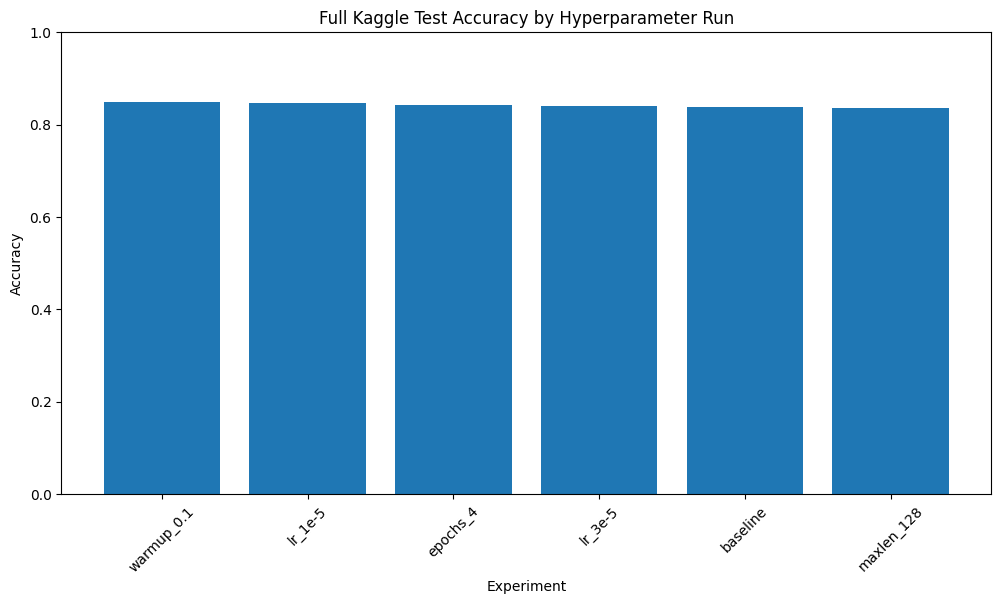

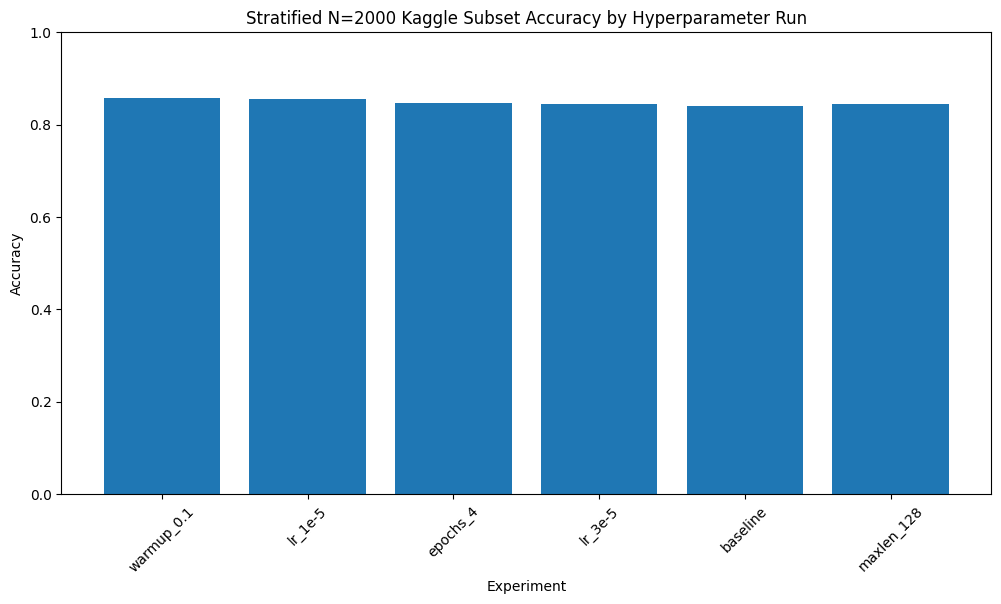

In [14]:
plot_df = results_df.sort_values(by="test_accuracy", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["name"], plot_df["test_accuracy"])
plt.title("Full Kaggle Test Accuracy by Hyperparameter Run")
plt.xlabel("Experiment")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(plot_df["name"], plot_df["subset_accuracy"])
plt.title("Stratified N=2000 Kaggle Subset Accuracy by Hyperparameter Run")
plt.xlabel("Experiment")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()


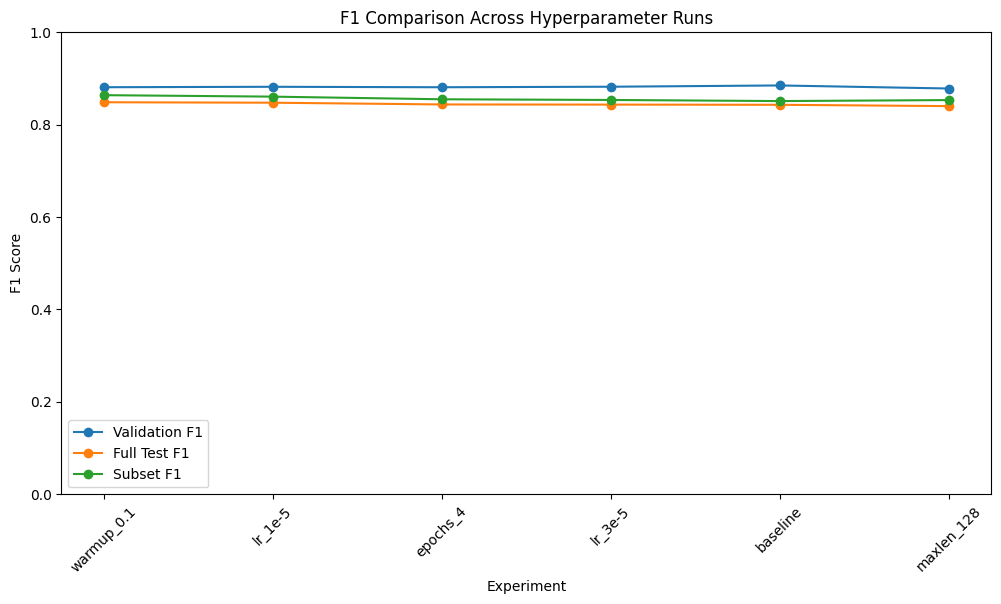

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(plot_df["name"], plot_df["val_f1"], marker="o", label="Validation F1")
plt.plot(plot_df["name"], plot_df["test_f1"], marker="o", label="Full Test F1")
plt.plot(plot_df["name"], plot_df["subset_f1"], marker="o", label="Subset F1")
plt.title("F1 Comparison Across Hyperparameter Runs")
plt.xlabel("Experiment")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.show()


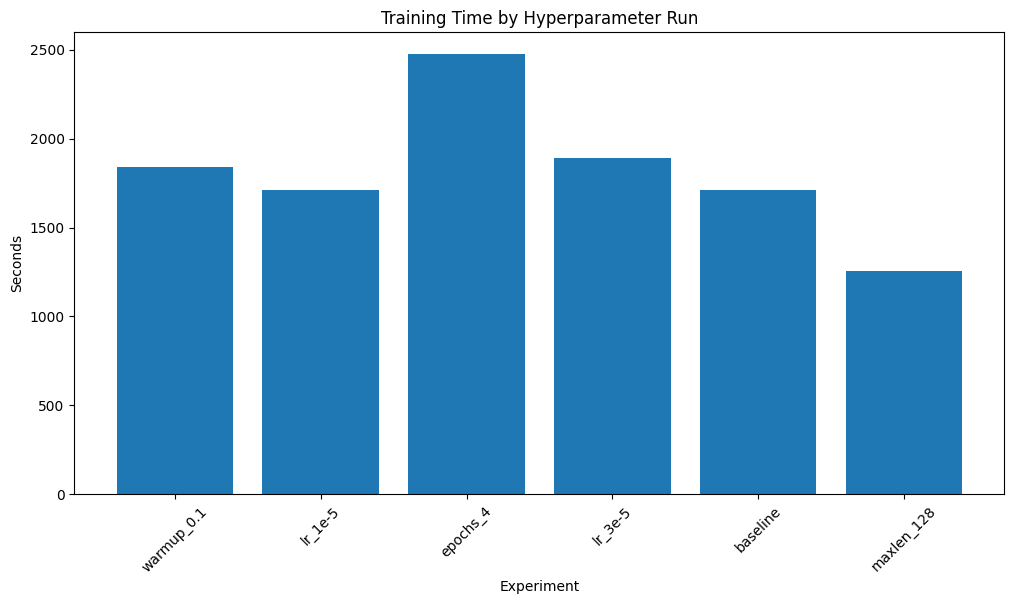

In [16]:
plt.figure(figsize=(12, 6))
plt.bar(plot_df["name"], plot_df["training_time_sec"])
plt.title("Training Time by Hyperparameter Run")
plt.xlabel("Experiment")
plt.ylabel("Seconds")
plt.xticks(rotation=45)
plt.show()


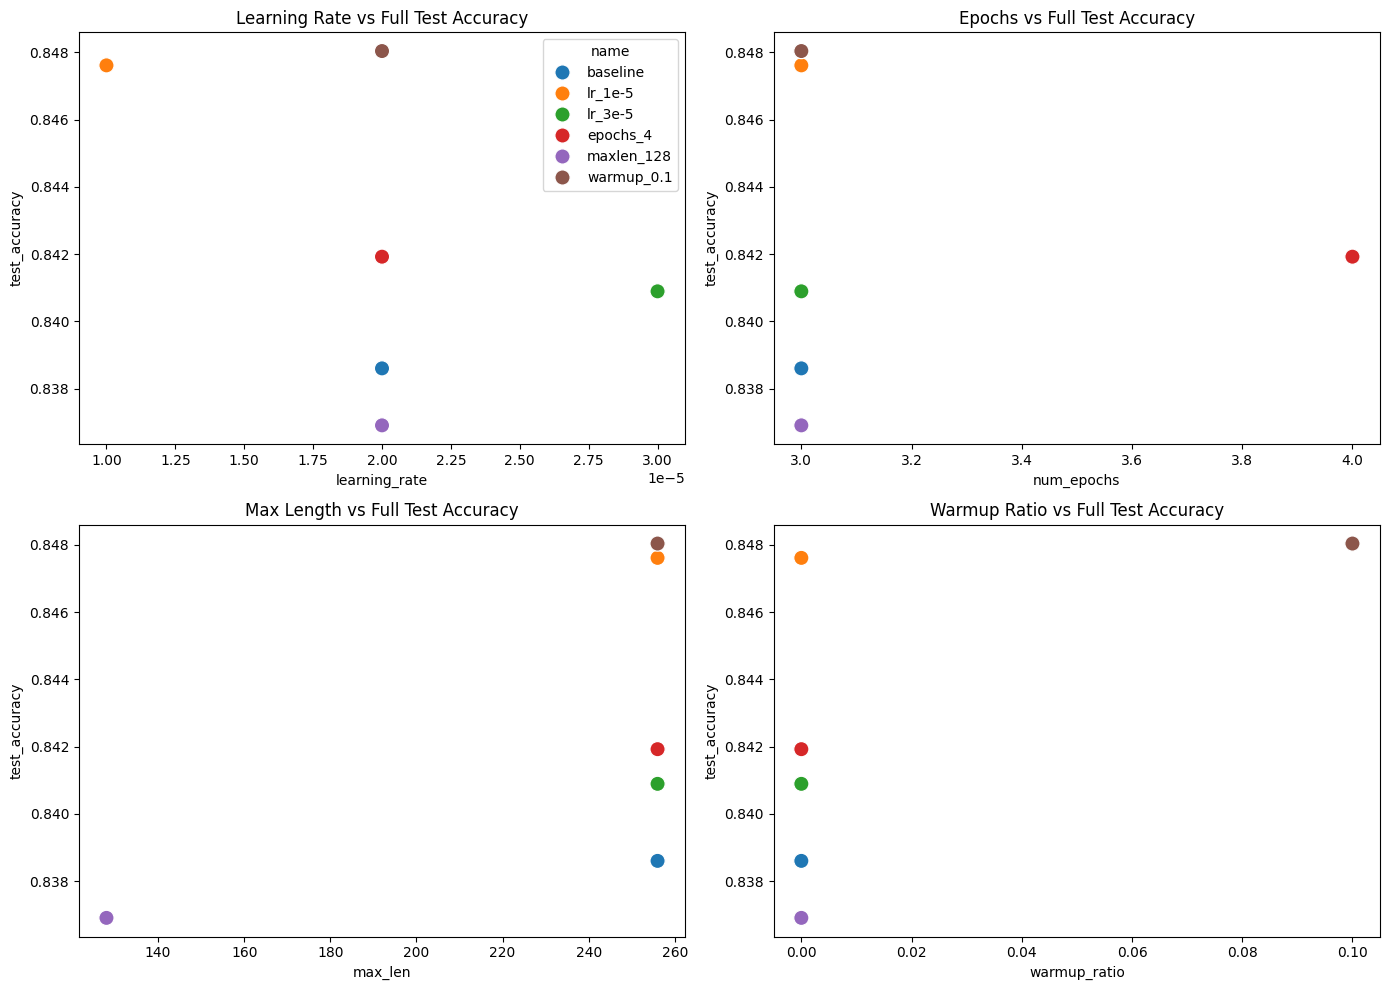

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=results_df, x="learning_rate", y="test_accuracy", hue="name", s=120, ax=axes[0,0])
axes[0,0].set_title("Learning Rate vs Full Test Accuracy")

sns.scatterplot(data=results_df, x="num_epochs", y="test_accuracy", hue="name", s=120, ax=axes[0,1], legend=False)
axes[0,1].set_title("Epochs vs Full Test Accuracy")

sns.scatterplot(data=results_df, x="max_len", y="test_accuracy", hue="name", s=120, ax=axes[1,0], legend=False)
axes[1,0].set_title("Max Length vs Full Test Accuracy")

sns.scatterplot(data=results_df, x="warmup_ratio", y="test_accuracy", hue="name", s=120, ax=axes[1,1], legend=False)
axes[1,1].set_title("Warmup Ratio vs Full Test Accuracy")

plt.tight_layout()
plt.show()


In [18]:
best_row = results_df.sort_values(by="test_accuracy", ascending=False).iloc[0]
best_row[[
    "name", "learning_rate", "batch_size", "num_epochs", "max_len",
    "weight_decay", "warmup_ratio", "test_accuracy", "test_f1",
    "subset_accuracy", "subset_f1", "training_time_sec"
]]


,5
name,warmup_0.1
learning_rate,0.00002
batch_size,16
num_epochs,3
max_len,256
weight_decay,0.01
warmup_ratio,0.1
test_accuracy,0.848039
test_f1,0.848551
subset_accuracy,0.8585


--- Confusion Matrix (Full Kaggle Test Set) ---
[[49606 12063]
 [ 5786 50003]]


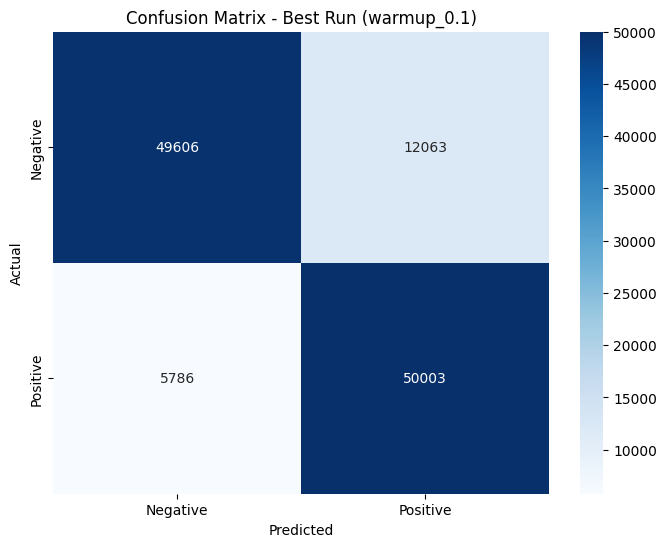


--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.90      0.80      0.85     61669
    Positive       0.81      0.90      0.85     55789

    accuracy                           0.85    117458
   macro avg       0.85      0.85      0.85    117458
weighted avg       0.85      0.85      0.85    117458



In [19]:
best_name = best_row["name"]
best_result = next(r for r in all_results if r["name"] == best_name)

cm = confusion_matrix(y_test, best_result["y_pred_full"])

print("--- Confusion Matrix (Full Kaggle Test Set) ---")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - Best Run ({best_name})")
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_test, best_result["y_pred_full"], target_names=["Negative", "Positive"]))


--- Confusion Matrix (N=2000 Subset) ---
[[819 181]
 [102 898]]


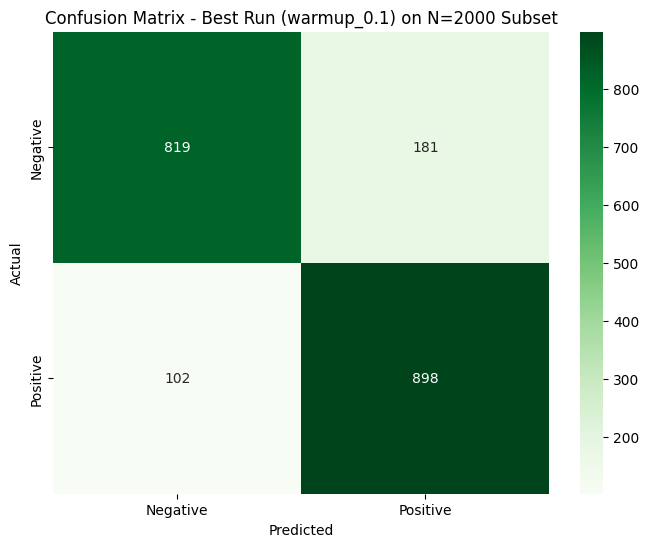


--- Classification Report (N=2000 Subset) ---
              precision    recall  f1-score   support

    Negative       0.89      0.82      0.85      1000
    Positive       0.83      0.90      0.86      1000

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



In [20]:
cm_sub = confusion_matrix(y_test_sub, best_result["y_pred_subset"])

print("--- Confusion Matrix (N=2000 Subset) ---")
print(cm_sub)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_sub, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - Best Run ({best_name}) on N=2000 Subset")
plt.show()

print("\n--- Classification Report (N=2000 Subset) ---")
print(classification_report(y_test_sub, best_result["y_pred_subset"], target_names=["Negative", "Positive"]))
